In [1]:
## import all necessary libraries along with cleaned dataset.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from Transformations.transformations import *


## DATA TRANSFORMATIONS

In [2]:
## IMPORT CLEANED DATASET
df=pd.read_csv(r"C:\Users\Administrator\OneDrive\Desktop\Case_Study\car_rental_cleaned_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Reservation_ID     7000 non-null   object 
 1   Customer_ID_x      7000 non-null   object 
 2   Vehicle_ID         7000 non-null   object 
 3   Vehicle_Class      7000 non-null   object 
 4   Booking_TS         7000 non-null   object 
 5   Pickup_TS          7000 non-null   object 
 6   Return_TS          7000 non-null   object 
 7   City               7000 non-null   object 
 8   Pickup_Lat         7000 non-null   float64
 9   Pickup_Lon         7000 non-null   float64
 10  Drop_Lat           7000 non-null   float64
 11  Drop_Lon           7000 non-null   float64
 12  Odo_Start_km       7000 non-null   int64  
 13  Odo_End_km         7000 non-null   int64  
 14  Fuel_Fraction      7000 non-null   float64
 15  Damage_Flag        7000 non-null   int64  
 16  GPS_Lat            7000 

1. Utilization = rental hours / fleet hours by city and vehicle class.


In [3]:
df = compute_utilization(df)
df[['Rental_Hours','Utilization']].head()


,Rental_Hours,Utilization
0,253.0,10.541667
1,127.0,5.291667
2,227.0,9.458333
3,112.0,4.666667
4,87.0,3.625000


2. Revenue per available car (RevPAC) and yield metrics.


In [4]:
df= compute_revpac(df)
df[['RevPAC']].head()

,RevPAC
0,42.0
1,70.0
2,105.0
3,105.0
4,70.0


3. Distance driven and cost per km.


In [5]:
# apply distance and cost
df = compute_distance_cost(df)

# check
df[['Distance_km','Cost_per_km']].head()

,Distance_km,Cost_per_km
0,1508,0.835544
1,619,3.392569
2,619,5.088853
3,826,3.813559
4,619,3.392569


4. Idle time and repositioning analytics.


In [6]:
# apply idle time
df = compute_idle_time(df)

# check
df[['Idle_Time']].head()

,Idle_Time
0,-229.0
1,-103.0
2,-203.0
3,-88.0
4,-63.0


5. Dynamic pricing features (demand, lead time, seasonality).


In [7]:
df = dynamic_pricing_features(df)

# df[['City', 'booking_date', 'Demand', 'Lead_Time_Hours', 'Month']].head()
df.loc[:, ['City', 'booking_date', 'Demand', 'Lead_Time_Hours', 'Month']].head()

,City,booking_date,Demand,Lead_Time_Hours,Month
0,Kolkata,2025-12-30,10,0.0,12
1,Chennai,2025-12-31,9,0.0,12
2,Chennai,2026-01-01,15,0.0,1
3,Bengaluru,2026-01-01,17,0.0,1
4,Kolkata,2026-01-02,15,0.0,1


        City  Demand
5     Mumbai   17269
3  Hyderabad   16398
2      Delhi   15691
4    Kolkata   15500
0  Bengaluru   15411
1    Chennai   14741


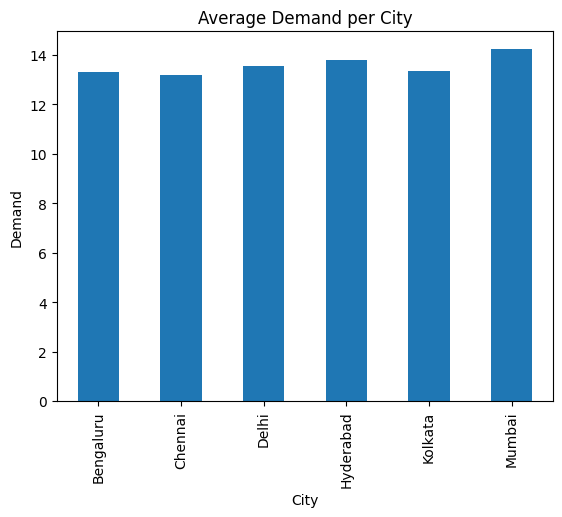

In [8]:
# Demand per city
demand_city = df.groupby('City')['Demand'].sum().reset_index()

print(demand_city.sort_values(by='Demand', ascending=False))
demand_city = df.groupby('City')['Demand'].mean()

demand_city.plot(kind='bar')
plt.title("Average Demand per City")
plt.xlabel("City")
plt.ylabel("Demand")
plt.show()

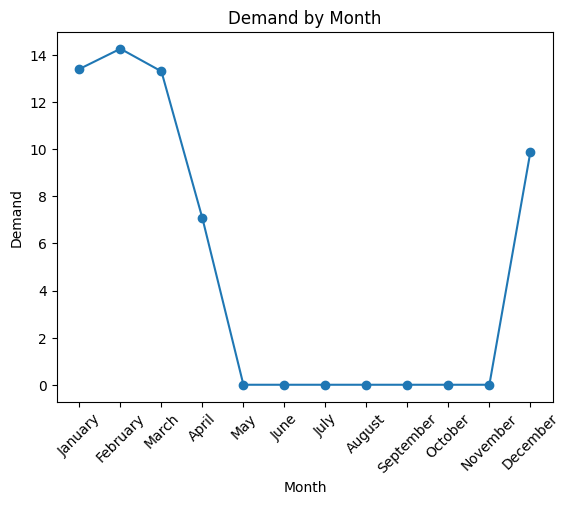

In [9]:
season_demand = df.groupby('Month')['Demand'].mean()

# ensure all 12 months are present
season_demand = season_demand.reindex(range(1, 13), fill_value=0)

# convert to month names
month_names = [calendar.month_name[i] for i in season_demand.index]

plt.plot(month_names, season_demand.values, marker='o')

plt.title("Demand by Month")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.show()
plt.show()

6. Fuel efficiency estimates by model.


In [10]:
df = fuel_efficiency(df)

df[['Vehicle_Class', 'Distance_km', 'Fuel_Used', 'Fuel_Efficiency']].head()

,Vehicle_Class,Distance_km,Fuel_Used,Fuel_Efficiency
0,Economy,1508,60.0,25.133333
1,Luxury,619,60.0,10.316667
2,Compact,619,60.0,10.316667
3,SUV,826,70.0,11.800000
4,Luxury,619,60.0,10.316667


7. Damage incidence rate per 100 rentals.


In [11]:
#7
damage_rate = damage_incidence_rate(df)

damage_rate

np.float64(17.79)

8. Customer cohort retention and NPS rollups.


In [12]:
df = cohort_retention(df)

df[['Customer_ID_x', 'Cohort_Month', 'Activity_Month', 'Cohort_Index']].head()

df['Cohort_Month'].value_counts()


Cohort_Month
2026-01    3394
2026-02    2038
2026-03    1375
2025-12     176
2026-04      17
Freq: M, Name: count, dtype: int64

In [13]:
# apply nps
NPS_Score = nps_rollups(df)

# check
# df[['Customer_Feedback','NPS_Category']].head()
df['NPS_Category'].value_counts()
NPS_Score

np.float64(40.54)

In [14]:
# apply nps
df = nps_rollups(df)

# check
df[['Customer_Feedback','NPS_Category','NPS_Score']].head()

IndexError: invalid index to scalar variable.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Reservation_ID     7000 non-null   object        
 1   Customer_ID_x      7000 non-null   object        
 2   Vehicle_ID         7000 non-null   object        
 3   Vehicle_Class      7000 non-null   object        
 4   Booking_TS         7000 non-null   datetime64[ns]
 5   Pickup_TS          7000 non-null   datetime64[ns]
 6   Return_TS          7000 non-null   object        
 7   City               7000 non-null   object        
 8   Pickup_Lat         7000 non-null   float64       
 9   Pickup_Lon         7000 non-null   float64       
 10  Drop_Lat           7000 non-null   float64       
 11  Drop_Lon           7000 non-null   float64       
 12  Odo_Start_km       7000 non-null   int64         
 13  Odo_End_km         7000 non-null   int64         
 14  Fuel_Fra

9. Fraud risk score (short returns, odometer anomalies).



<Axes: xlabel='Fraud_Flag'>

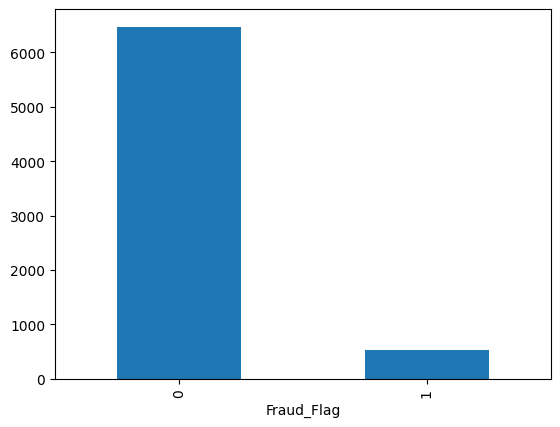

In [ ]:
df=fraud_risk(df)
df['Fraud_Flag'].value_counts(normalize=True) * 100
df.groupby('Fraud_Flag')['Total_Amount'].mean()
df['Fraud_Flag'].value_counts().plot(kind='bar')

10. Maintenance due forecast (km/time based).


In [ ]:
# apply maintenance
df = prepare_maintenance_features(df)
df = maintenance_due_forecast(df)

df[['KM_Since_Service', 'Days_Since_Trip', 'Maintenance_Due']].head()


,KM_Since_Service,Days_Since_Trip,Maintenance_Due
0,1508,10,1
1,619,5,0
2,619,9,0
3,826,4,1
4,619,3,0


11. Overstay detection and penalty calculation.


In [ ]:
# apply
df = overstay_detection(df)

# check
print(df[['Rental_Hours', 'Overstay', 'Overstay_Hours', 'Penalty_Amount']].head(5))



   Rental_Hours  Overstay  Overstay_Hours  Penalty_Amount
0         253.0         1           229.0            2000
1         127.0         1           103.0            2000
2         227.0         1           203.0            2000
3         112.0         1            88.0            2000
4          87.0         1            63.0            2000


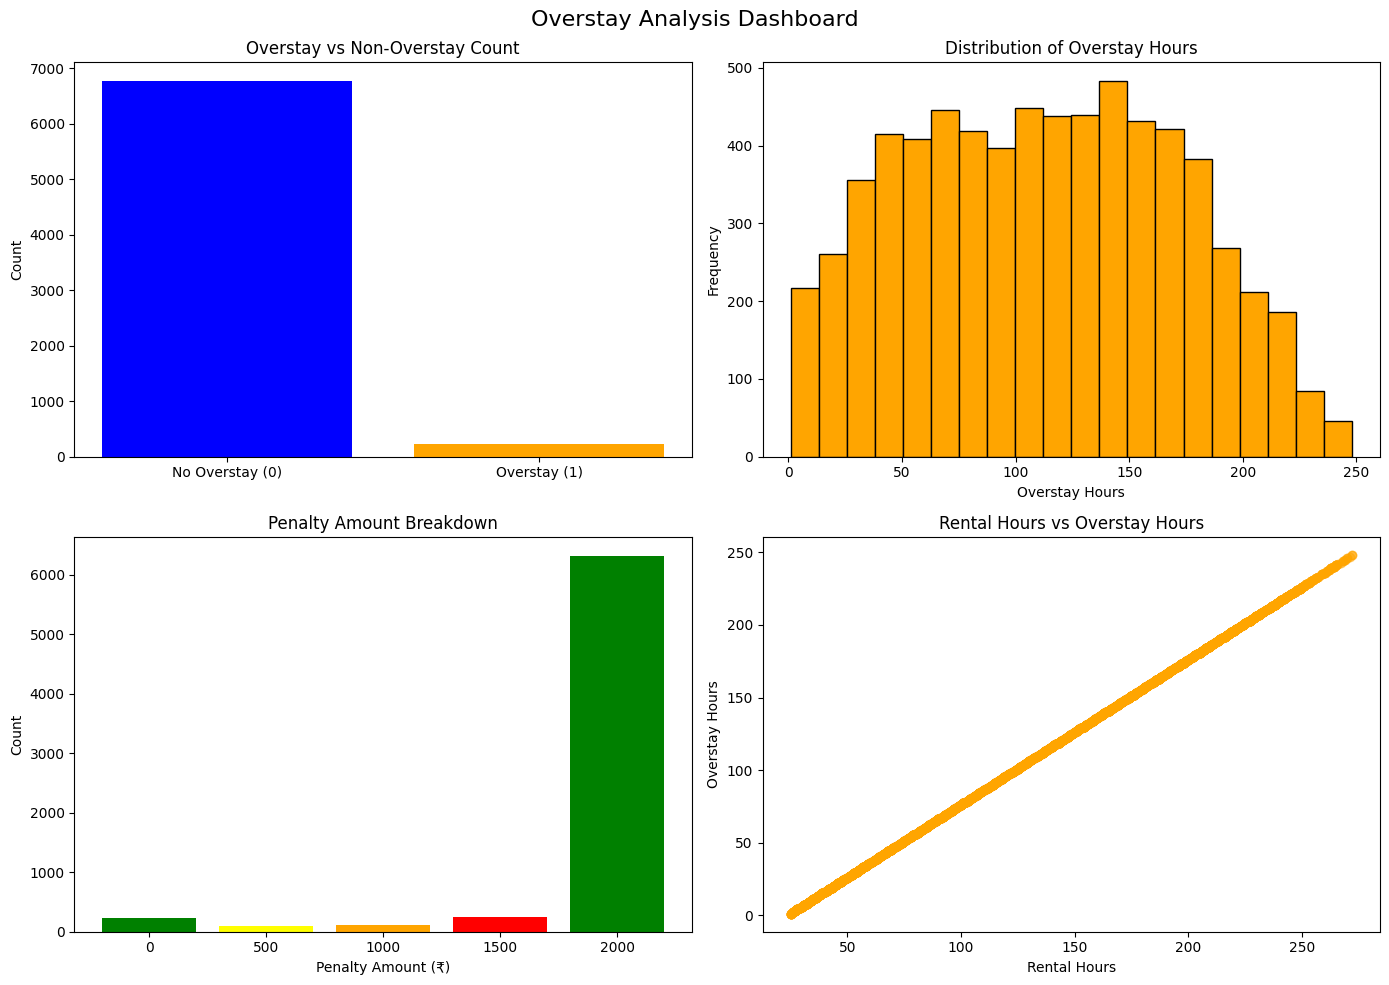

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overstay Analysis Dashboard', fontsize=16)

# 1 — Overstay vs Non-Overstay count
overstay_counts = df['Overstay'].value_counts()
axes[0,0].bar(['No Overstay (0)', 'Overstay (1)'], 
               overstay_counts.values, 
               color=['blue', 'orange'])
axes[0,0].set_title('Overstay vs Non-Overstay Count')
axes[0,0].set_ylabel('Count')

# 2 — Distribution of Overstay Hours
overstay_df = df[df['Overstay'] == 1]
axes[0,1].hist(overstay_df['Overstay_Hours'], bins=20, color='orange', edgecolor='black')
axes[0,1].set_title('Distribution of Overstay Hours')
axes[0,1].set_xlabel('Overstay Hours')
axes[0,1].set_ylabel('Frequency')

# 3 — Penalty Amount breakdown
penalty_counts = df['Penalty_Amount'].value_counts().sort_index()
axes[1,0].bar(penalty_counts.index.astype(str), 
               penalty_counts.values, 
               color=['green','yellow','orange','red'])
axes[1,0].set_title('Penalty Amount Breakdown')
axes[1,0].set_xlabel('Penalty Amount (₹)')
axes[1,0].set_ylabel('Count')

# 4 — Rental Hours vs Overstay Hours scatter
axes[1,1].scatter(overstay_df['Rental_Hours'], 
                   overstay_df['Overstay_Hours'],
                   color='orange', alpha=0.5)
axes[1,1].set_title('Rental Hours vs Overstay Hours')
axes[1,1].set_xlabel('Rental Hours')
axes[1,1].set_ylabel('Overstay Hours')

plt.tight_layout()
plt.show()

12. Pickup/return punctuality stats.


In [ ]:
# apply punctuality
df = pickup_punctuality(df)

# check
df[['Delay']].head()
df['Delay'].value_counts()

Delay
0.0     5712
36.0      28
30.0      26
23.0      26
19.0      25
        ... 
57.0      12
38.0      12
29.0      12
46.0      11
21.0      10
Name: count, Length: 73, dtype: int64

13. Geo heatmaps of pickup/drop hotspots.


In [ ]:
# apply geo hotspots
df = geo_hotspots(df)

# check
df[['Location']].head()

,Location
0,Kolkata
1,Chennai
2,Chennai
3,Bengaluru
4,Kolkata


14. Upsell/cross‑sell opportunity flags (addons).


In [ ]:
# apply upsell
df = upsell_flags(df)

# check
df[['Upsell']].head()

,Upsell
0,1
1,1
2,1
3,0
4,0


15. Cancellation rate and reasons analysis.


In [ ]:
# apply cancellation
df = cancellation_rate(df)

# check
df[['Cancelled']].head()

,Cancelled
0,0
1,0
2,0
3,0
4,0


16. Driver behavior scoring from telematics.


In [ ]:
# apply driver behavior
df = driver_behavior(df)

# check
df[['Risky_Driver']].head()

,Risky_Driver
0,0
1,0
2,0
3,0
4,0


17. Vehicle class mix optimization.


In [ ]:
# apply vehicle mix
df = vehicle_mix(df)

# check
df[['Vehicle_Class','Vehicle_Count']].head()

,Vehicle_Class,Vehicle_Count
0,Economy,1710
1,Luxury,1801
2,Compact,1778
3,SUV,1711
4,Luxury,1801


18. Lead‑time price elasticity features.


In [ ]:
# apply price elasticity
df = price_elasticity(df)

# check
df[['Price_per_Demand']].head()

,Price_per_Demand
0,126.000000
1,233.333333
2,210.000000
3,185.294118
4,140.000000


19. Fleet health score combining faults and usage.


In [ ]:
# apply fleet health
df = fleet_health(df)

# check
df[['Fleet_Health']].value_counts()

Fleet_Health
Good            5755
Bad             1245
Name: count, dtype: int64

20. Churn likelihood for subscription rentals.

In [ ]:
# apply churn prediction
df = churn_prediction(df)

# check
df[['Customer_ID_x','Days_Since_Last_Booking','Churn_Flag']].head(10)
df['Churn_Flag'].value_counts()

Churn_Flag
1    3721
0    3279
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Reservation_ID           7000 non-null   object        
 1   Customer_ID_x            7000 non-null   object        
 2   Vehicle_ID               7000 non-null   object        
 3   Vehicle_Class            7000 non-null   object        
 4   Booking_TS               7000 non-null   datetime64[ns]
 5   Pickup_TS                7000 non-null   datetime64[ns]
 6   Return_TS                7000 non-null   datetime64[ns]
 7   City                     7000 non-null   object        
 8   Pickup_Lat               7000 non-null   float64       
 9   Pickup_Lon               7000 non-null   float64       
 10  Drop_Lat                 7000 non-null   float64       
 11  Drop_Lon                 7000 non-null   float64       
 12  Odo_Start_km             7000 non-

In [ ]:
df.to_csv("car_rental_transformed.csv",index=False)